# Survival Analysis with nestkit

This notebook demonstrates **nested cross-validation for survival analysis** using `NestedCVSurvival` and `CoxPHWrapper`  -  a scikit-learn compatible wrapper around lifelines' `CoxPHFitter`.

## What you'll learn

1. How to prepare survival data for nestkit
2. How to run nested CV with a Cox proportional hazards model
3. How to inspect concordance indices, integrated Brier score, and coefficient stability
4. How to tune regularization (penalizer + elastic net)
5. How to use extra prediction methods (survival functions, median survival)

## Prerequisites

```bash
pip install nestkit[survival]
```

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines.datasets import load_rossi

from nestkit import NestedCVSurvival
from nestkit.survival import CoxPHWrapper, make_survival_target

warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## 1. Data Preparation

We'll use the **Rossi recidivism** dataset from lifelines (432 samples, 7 features). It tracks whether released prisoners were rearrested (`arrest`) and the time until rearrest or end of follow-up (`week`).

Survival data has two targets:
- **Event indicator**  -  did the event of interest occur? (1 = yes, 0 = censored)
- **Duration**  -  time until the event or censoring

In [ ]:
rossi = load_rossi()
print(f"Shape: {rossi.shape}")
print(
    f"Event rate: {rossi['arrest'].mean():.1%} (censoring rate: {1 - rossi['arrest'].mean():.1%})"
)
rossi.head()

Shape: (432, 9)
Event rate: 26.4% (censoring rate: 73.6%)


,week,arrest,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


In [ ]:
# Separate features from targets
feature_cols = [c for c in rossi.columns if c not in ("week", "arrest")]
X = rossi[feature_cols]

# Create the survival target using make_survival_target
y = make_survival_target(event=rossi["arrest"].values, duration=rossi["week"].values)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}  (columns: [event, duration])")
print(f"Feature names: {feature_cols}")

X shape: (432, 7)
y shape: (432, 2)  (columns: [event, duration])
Feature names: ['fin', 'age', 'race', 'wexp', 'mar', 'paro', 'prio']


### Alternative target formats

`NestedCVSurvival` also accepts targets as:
- A **pandas DataFrame** with `"event"` and `"duration"` columns
- A **numpy structured array** with `"event"` and `"duration"` fields

The target is automatically detected and normalized internally.

In [ ]:
y_df = pd.DataFrame({"event": rossi["arrest"].values, "duration": rossi["week"].values})

dt = np.dtype([("event", np.float64), ("duration", np.float64)])
y_struct = np.array(list(zip(rossi["arrest"].values, rossi["week"].values)), dtype=dt)

print(f"ndarray:    shape={y.shape}, dtype={y.dtype}")
print(f"DataFrame:  shape={y_df.shape}, columns={list(y_df.columns)}")
print(f"Structured: shape={y_struct.shape}, dtype={y_struct.dtype}")

ndarray:    shape=(432, 2), dtype=float64
DataFrame:  shape=(432, 2), columns=['event', 'duration']
Structured: shape=(432,), dtype=[('event', '<f8'), ('duration', '<f8')]


## 2. Basic Nested CV with CoxPHWrapper

`CoxPHWrapper` adapts lifelines' `CoxPHFitter` to the sklearn `fit(X, y)` / `predict(X)` interface.  This makes it compatible with `GridSearchCV`, `RandomizedSearchCV`, and `NestedCVSurvival`.

Key parameters for tuning:
- **`penalizer`**  -  regularization strength (L1/L2 penalty)
- **`l1_ratio`**  -  elastic net mixing (0 = pure L2/Ridge, 1 = pure L1/Lasso)

`predict(X)` returns **log-partial hazard** (risk scores): higher values indicate higher risk.

In [ ]:
ncv = NestedCVSurvival(
    estimator=CoxPHWrapper(),
    param_grid={"penalizer": [0.001, 0.01, 0.1, 1.0, 10.0]},
    outer_cv=5,
    inner_cv=3,
    random_state=42,
)
ncv.fit(X, y)

,estimator,CoxPHWrapper()
,param_grid,"{'penalizer': [0.001, 0.01, ...]}"
,search_strategy,'grid'
,outer_cv,5
,inner_cv,3
,scoring,None
,refit,True
,return_train_score,False
,return_estimator,True
,error_score,'raise'
,n_jobs_outer,None


## 3. Inspecting Results

The results object provides:
- **Concordance indices**  -  Harrell's and Uno's (IPCW-weighted, more robust to censoring)
- **Integrated Brier score**  -  calibration metric (lower is better)
- **Coefficient stability**  -  how consistent are the hazard ratios across folds?
- **Generalization gap**  -  difference between inner CV score and outer test score

In [ ]:
results = ncv.results_
print("Summary statistics (with Nadeau-Bengio corrected CIs):")
results.summary_default_

Summary statistics (with Nadeau-Bengio corrected CIs):


,metric,mean,std,ci_lower,ci_upper,median,iqr
0,concordance_index,0.623339,0.050805,0.528714,0.717964,0.594929,0.082040
1,uno_c_index,0.626350,0.055507,0.522968,0.729732,0.605634,0.091740
2,integrated_brier_score,0.109544,0.017905,0.076197,0.142891,0.110966,0.012165


In [ ]:
print("Per-fold scores:")
results.outer_scores_default_

Per-fold scores:


,concordance_index,uno_c_index,integrated_brier_score
0,0.575466,0.575969,0.114870
1,0.671893,0.671893,0.110966
2,0.594929,0.605634,0.102705
3,0.684552,0.698102,0.085042
4,0.589853,0.580153,0.134137


In [ ]:
print("Best hyperparameters per fold:")
for i, params in enumerate(results.best_params_per_fold_):
    print(f"  Fold {i}: {params}")

Best hyperparameters per fold:
  Fold 0: {'penalizer': 10.0}
  Fold 1: {'penalizer': 10.0}
  Fold 2: {'penalizer': 10.0}
  Fold 3: {'penalizer': 10.0}
  Fold 4: {'penalizer': 1.0}


In [ ]:
print("Predictions DataFrame:")
results.predictions_.head(10)

Predictions DataFrame:


,y_event,y_duration,risk_score,fold_idx
0,True,20.0,0.007039,3
1,True,17.0,0.043632,0
2,True,25.0,0.025118,1
3,False,52.0,-0.028118,3
4,False,52.0,0.014801,4
5,False,52.0,-0.001708,2
6,True,23.0,-0.029492,3
7,False,52.0,0.000088,1
8,False,52.0,0.029193,1
9,False,52.0,-0.000167,1


In [ ]:
print("Coefficient stability:")
results.coefficient_stability_

Coefficient stability:


,feature,coef_mean,coef_std,hazard_ratio_mean,hazard_ratio_std
0,age,-0.003116,0.003808,0.996894,0.003786
1,fin,-0.026499,0.039648,0.974451,0.037630
2,mar,-0.036255,0.049417,0.965316,0.046133
3,paro,-0.010239,0.018406,0.989946,0.018009
4,prio,0.007319,0.010015,1.007387,0.010157
5,race,0.017563,0.028012,1.018041,0.029018
6,wexp,-0.027290,0.026171,0.973343,0.025027


In [ ]:
results.generalization_gap_

,fold_idx,best_inner_score,outer_concordance_index,outer_uno_c_index,outer_integrated_brier_score
0,0,0.606143,0.575466,0.575969,0.114870
1,1,0.626764,0.671893,0.671893,0.110966
2,2,0.649072,0.594929,0.605634,0.102705
3,3,0.585837,0.684552,0.698102,0.085042
4,4,0.640444,0.589853,0.580153,0.134137


## 4. Advanced: Tuning Penalizer + L1 Ratio (Elastic Net)

Cox PH with elastic net regularization provides a flexible penalty that combines L1 (feature selection) and L2 (shrinkage). This is especially useful with many correlated features.

In [ ]:
ncv_elastic = NestedCVSurvival(
    estimator=CoxPHWrapper(),
    param_grid={
        "penalizer": [0.001, 0.01, 0.1, 1.0],
        "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
    },
    outer_cv=5,
    inner_cv=3,
    random_state=42,
)
ncv_elastic.fit(X, y)
results_elastic = ncv_elastic.results_

In [ ]:
print("Elastic net results:")
display(results_elastic.summary_default_)

print("\nBest params per fold:")
for i, params in enumerate(results_elastic.best_params_per_fold_):
    print(f"  Fold {i}: {params}")

print("\nCoefficient stability (elastic net):")
results_elastic.coefficient_stability_

Elastic net results:


,metric,mean,std,ci_lower,ci_upper,median,iqr
0,concordance_index,0.612472,0.063109,0.494932,0.730012,0.596108,0.095848
1,uno_c_index,0.621030,0.061240,0.506971,0.735089,0.606859,0.095369
2,integrated_brier_score,0.109980,0.018012,0.076432,0.143527,0.111473,0.012126



Best params per fold:
  Fold 0: {'l1_ratio': 0.75, 'penalizer': 1.0}
  Fold 1: {'l1_ratio': 0.75, 'penalizer': 1.0}
  Fold 2: {'l1_ratio': 0.25, 'penalizer': 1.0}
  Fold 3: {'l1_ratio': 0.5, 'penalizer': 1.0}
  Fold 4: {'l1_ratio': 0.75, 'penalizer': 0.1}

Coefficient stability (elastic net):


,feature,coef_mean,coef_std,hazard_ratio_mean,hazard_ratio_std
0,age,-9.132557e-04,2.042027e-03,0.999089,2.037372e-03
1,fin,-2.501065e-07,1.377569e-07,1.000000,1.377569e-07
2,mar,-4.034617e-07,1.650515e-07,1.000000,1.650514e-07
3,paro,-7.962655e-08,9.407048e-08,1.000000,9.407047e-08
4,prio,5.629457e-03,1.258770e-02,1.005709,1.276653e-02
5,race,1.580020e-07,1.290431e-07,1.000000,1.290431e-07
6,wexp,-3.706559e-07,4.708790e-08,1.000000,4.708788e-08


## 5. Using Extra Prediction Methods

Beyond risk scores, `CoxPHWrapper` provides:
- **`predict_survival_function(X)`**  -  full survival curves S(t|X)
- **`predict_median(X)`**  -  predicted median survival time

These use the fitted model from one of the outer folds.

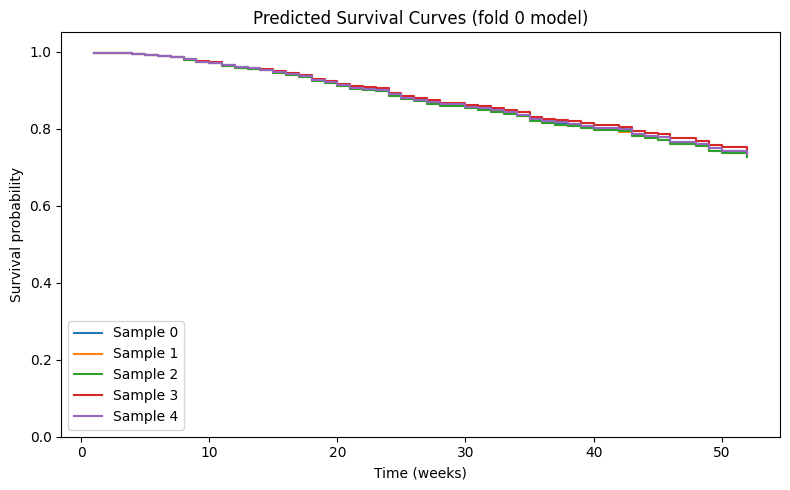

In [ ]:
fold0_estimator = results.fold_results_[0].fitted_estimator

sample_X = X.iloc[:5]
sf = fold0_estimator.predict_survival_function(sample_X)

fig, ax = plt.subplots(figsize=(8, 5))
for col in sf.columns:
    ax.step(sf.index, sf[col], where="post", label=f"Sample {col}")
ax.set_xlabel("Time (weeks)")
ax.set_ylabel("Survival probability")
ax.set_title("Predicted Survival Curves (fold 0 model)")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()

In [ ]:
medians = fold0_estimator.predict_median(X.iloc[:10])
print("Predicted median survival times (weeks):")
for i, m in enumerate(medians):
    actual_event = "event" if y[i, 0] == 1 else "censored"
    median_str = f"{m:.0f}" if np.isfinite(m) else "inf (S(t) > 0.5 for all t)"
    print(f"  Sample {i}: {median_str}  (observed: {y[i, 1]:.0f} weeks, {actual_event})")

print("\nSurvival probability at t=26 weeks (6 months):")
sf_26 = fold0_estimator.predict_survival_function(X.iloc[:10], times=[26.0])
for i in range(10):
    actual_event = "event" if y[i, 0] == 1 else "censored"
    print(
        f"  Sample {i}: S(26) = {sf_26.iloc[0, i]:.3f}  (observed: {y[i, 1]:.0f} weeks, {actual_event})"
    )

Predicted median survival times (weeks):
  Sample 0: inf (S(t) > 0.5 for all t)  (observed: 20 weeks, event)
  Sample 1: inf (S(t) > 0.5 for all t)  (observed: 17 weeks, event)
  Sample 2: inf (S(t) > 0.5 for all t)  (observed: 25 weeks, event)
  Sample 3: inf (S(t) > 0.5 for all t)  (observed: 52 weeks, censored)
  Sample 4: inf (S(t) > 0.5 for all t)  (observed: 52 weeks, censored)
  Sample 5: inf (S(t) > 0.5 for all t)  (observed: 52 weeks, censored)
  Sample 6: inf (S(t) > 0.5 for all t)  (observed: 23 weeks, event)
  Sample 7: inf (S(t) > 0.5 for all t)  (observed: 52 weeks, censored)
  Sample 8: inf (S(t) > 0.5 for all t)  (observed: 52 weeks, censored)
  Sample 9: inf (S(t) > 0.5 for all t)  (observed: 52 weeks, censored)

Survival probability at t=26 weeks (6 months):
  Sample 0: S(26) = 0.874  (observed: 20 weeks, event)
  Sample 1: S(26) = 0.871  (observed: 17 weeks, event)
  Sample 2: S(26) = 0.871  (observed: 25 weeks, event)
  Sample 3: S(26) = 0.879  (observed: 52 weeks, 

## Next Steps

- Explore the results with the **diagnostics** module (`HyperparameterStability`) for deeper parameter stability analysis
- Use `results.to_json()` or `results.to_latex()` for exporting results
- Compare survival models with different regularization settings using `NestedCVComparator`
- See **[01  -  Basic Usage](01_basic_usage.ipynb)** and **[02  -  Advanced Workflows](02_advanced_workflows.ipynb)** for classification and regression examples